In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

diet = pd.read_csv("stcp-Rdataset-Diet.csv")
penguins = pd.read_csv("penguins.csv")
heroes = pd.read_csv("heroes_clean.csv")
url_backpack = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/Stat2Data/Backpack.csv"
backpack = pd.read_csv(url_backpack)

In [8]:
# Lab 28 Двухвыборочный зависимый t-test



diet2 = diet[diet['Diet'] == 2].dropna(subset=['pre.weight', 'weight6weeks'])
diet3 = diet[diet['Diet'] == 3].dropna(subset=['pre.weight', 'weight6weeks'])

t_rel_2, p_rel_2 = stats.ttest_rel(diet2['pre.weight'], diet2['weight6weeks'])
t_rel_3, p_rel_3 = stats.ttest_rel(diet3['pre.weight'], diet3['weight6weeks'])

print(f"""
Диета 2 (До vs После): p-value = {p_rel_2:.3e}
Диета 3 (До vs После): p-value = {p_rel_3:.3e}\n
Было проведено исследование: изменился ли вес людей внутри каждой группы после 6 недель диеты.
Диета 2 (p-value = 1.360e-06): Значение 0.00000136 меньше 0.05.
Диета 3 (p-value = 2.030e-11): Значение 0.00000000002 сильно меньше 0.05.
Интерпретация: Обе диеты работают. Изменения веса испытуемых до и после диеты 
статистически значимы. 
Это не случайное колебание веса, диеты действительно привели к похудению.
""")



Диета 2 (До vs После): p-value = 1.360e-06
Диета 3 (До vs После): p-value = 2.030e-11

Было проведено исследование: изменился ли вес людей внутри каждой группы после 6 недель диеты.
Диета 2 (p-value = 1.360e-06): Значение 0.00000136 меньше 0.05.
Диета 3 (p-value = 2.030e-11): Значение 0.00000000002 сильно меньше 0.05.
Интерпретация: Обе диеты работают. Изменения веса испытуемых до и после диеты 
статистически значимы. 
Это не случайное колебание веса, диеты действительно привели к похудению.



In [14]:
# Lab 29 Двухвыборочный зависимый t-test



diet1 = diet[diet['Diet'] == 1].dropna(subset=['weight6weeks'])

t_ind_23, p_ind_23 = stats.ttest_ind(diet2['weight6weeks'], diet3['weight6weeks'])
t_ind_13, p_ind_13 = stats.ttest_ind(diet1['weight6weeks'], diet3['weight6weeks'])

print(f"Сравнение диет 2 и 3 (результат): p-value = {p_ind_23:.3f}")
print(f"Сравнение диет 1 и 3 (результат): p-value = {p_ind_13:.3f}\nСтатистически значимой разницы в финальном весе между группами нет.")

black_eyes = heroes[heroes['Eye color'] == 'black']['Weight'].dropna()
white_eyes = heroes[heroes['Eye color'] == 'white']['Weight'].dropna()

t_eyes, p_eyes = stats.ttest_ind(black_eyes, white_eyes, equal_var=False) # Указываем False для поправки Уэлча
print(f"\nВес героев (Черные vs Белые глаза): p-value = {p_eyes:.3f}\nИнтерпретация: Вес супергероев никак не зависит от того, черные у них глаза или белые.\nРазница средних весов в этих группах — просто случайность выборки.")

Сравнение диет 2 и 3 (результат): p-value = 0.876
Сравнение диет 1 и 3 (результат): p-value = 0.641
Статистически значимой разницы в финальном весе между группами нет.

Вес героев (Черные vs Белые глаза): p-value = 0.872
Интерпретация: Вес супергероев никак не зависит от того, черные у них глаза или белые.
Разница средних весов в этих группах — просто случайность выборки.


In [18]:
# Lab 30 Непараметрические тесты



mw_12 = stats.mannwhitneyu(diet1['weight6weeks'], diet2['weight6weeks'])
mw_23 = stats.mannwhitneyu(diet2['weight6weeks'], diet3['weight6weeks'])
mw_13 = stats.mannwhitneyu(diet1['weight6weeks'], diet3['weight6weeks'])
print(f"Манна-Уитни (Диеты 1 vs 2): p-value = {mw_12.pvalue:.3f}\nЗначение больше 0.05. Интерпретация: Как и в случае с независимым t-тестом,\nэтот тест подтверждает, что финальный абсолютный вес у людей,\nсидевших на первой и второй диете, статистически не отличается.\n")

w_1 = stats.wilcoxon(diet1['pre.weight'], diet1['weight6weeks'])
print(f"Уилкоксон (Диета 1, До vs После): p-value = {w_1.pvalue:.3e}\nКак и в случае с зависимым t-тестом, этот тест подтверждает, \nчто первая диета тоже эффективна. Вес людей 'До' статистически значимо отличается от их веса 'После'.")

Манна-Уитни (Диеты 1 vs 2): p-value = 0.412
Значение больше 0.05. Интерпретация: Как и в случае с независимым t-тестом,
этот тест подтверждает, что финальный абсолютный вес у людей,
сидевших на первой и второй диете, статистически не отличается.

Уилкоксон (Диета 1, До vs После): p-value = 2.067e-05
Как и в случае с зависимым t-тестом, этот тест подтверждает, 
что первая диета тоже эффективна. Вес людей 'До' статистически значимо отличается от их веса 'После'.


Средний вес рюкзака (кг) по полу:
         backpack_kg
Sex                
Female     5.006010
Male       5.634625
T-test (Вес рюкзаков, М vs Ж): p-value = 0.234

Средний вес тела (кг) по полу:
           body_kg
Sex              
Female  62.282356
Male    78.148925
T-test (Вес тела, М vs Ж): p-value = 6.696e-11


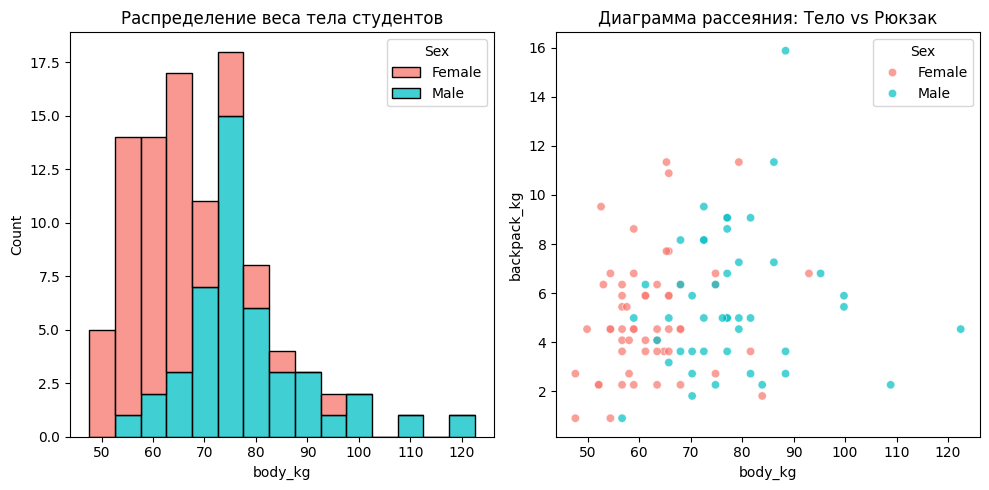

In [20]:
# Lab 32 Исследование набора данных Backpack



backpack['backpack_kg'] = backpack['BackpackWeight'] * 0.45359237
backpack['body_kg'] = backpack['BodyWeight'] * 0.45359237

bp_means = backpack.groupby('Sex')[['backpack_kg']].mean()
print("Средний вес рюкзака (кг) по полу:\n", bp_means)

male_bp = backpack[backpack['Sex'] == 'Male']['backpack_kg'].dropna()
female_bp = backpack[backpack['Sex'] == 'Female']['backpack_kg'].dropna()
t_bp, p_bp = stats.ttest_ind(male_bp, female_bp)
print(f"T-test (Вес рюкзаков, М vs Ж): p-value = {p_bp:.3f}")

body_means = backpack.groupby('Sex')[['body_kg']].mean()
print("\nСредний вес тела (кг) по полу:\n", body_means)

male_body = backpack[backpack['Sex'] == 'Male']['body_kg'].dropna()
female_body = backpack[backpack['Sex'] == 'Female']['body_kg'].dropna()
t_body, p_body = stats.ttest_ind(male_body, female_body)
print(f"T-test (Вес тела, М vs Ж): p-value = {p_body:.3e}")


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=backpack, x='body_kg', hue='Sex', multiple='stack', bins=15, palette={'Female': '#F8766D', 'Male': '#00BFC4'})
plt.title("Распределение веса тела студентов")

plt.subplot(1, 2, 2)
sns.scatterplot(data=backpack, x='body_kg', y='backpack_kg', hue='Sex', alpha=0.7, palette={'Female': '#F8766D', 'Male': '#00BFC4'})
plt.title("Диаграмма рассеяния: Тело vs Рюкзак")

plt.tight_layout()
plt.show()

In [25]:
# Lab 32 Ковариация и коэффициент корреляции



cov_lbs = np.cov(backpack['BackpackWeight'], backpack['BodyWeight'], ddof=1)[0, 1]
cov_kg = np.cov(backpack['backpack_kg'], backpack['body_kg'], ddof=1)[0, 1]
print(f"""Ковариация (Фунты): {cov_lbs:.3f}\nКовариация (Килограммы): {cov_kg:.3f}
Ковариации отличаются. Ковариация напрямую зависит от единиц измерения данных.
Поскольку 1 килограмм — это примерно 2.2 фунта, значения веса в фунтах численно больше. 
При умножении разбросов, разница возводится в квадрат (2.2*2.2 около 4.8). 
Если умножить ковариацию в килограммах (6.602) на 4.84, вы получите как раз около 32.
Именно поэтому ковариацию почти никогда не используют в чистом виде для оценки силы связи — 
глядя на число 32, невозможно сказать, сильная это связь или слабая, так как масштаб неизвестен.
""")
print(f"")


corr_lbs, p_corr_lbs = stats.pearsonr(backpack['BackpackWeight'], backpack['BodyWeight'])
corr_kg, p_corr_kg = stats.pearsonr(backpack['backpack_kg'], backpack['body_kg'])
print(f"\nКорреляция Пирсона (Фунты): r = {corr_lbs:.3f}, p-value = {p_corr_lbs:.3f}")
print(f"""Корреляция Пирсона (Килограммы): r = {corr_kg:.3f}, p-value = {p_corr_kg:.3f}\n
Коэффициент корреляции Пирсона — это стандартизированная ковариация. В его формуле ковариация
делится на произведение стандартных отклонений обеих переменных. 
При этом делении единицы измерения (фунты или килограммы) математически сокращаются.""")

print("\nКорреляции для супергероев (Рост vs Вес):")
heroes_clean = heroes.dropna(subset=['Height', 'Weight'])

corr_p, _ = stats.pearsonr(heroes_clean['Height'], heroes_clean['Weight'])
corr_s, _ = stats.spearmanr(heroes_clean['Height'], heroes_clean['Weight'])
corr_k, _ = stats.kendalltau(heroes_clean['Height'], heroes_clean['Weight'])
print(f"""Кендалл: tau = {corr_k:.3f}
Пирсон: r = {corr_p:.3f}
Спирмен: rho = {corr_s:.3f}\n
Пирсон (r = 0.193): Показывает ложно-слабую связь. 
Он ищет строгую прямую линию и «ломается» из-за экстремальных выбросов (героев-гигантов).
Спирмен (0.800) и Кендалл (0.675): Отражают реальную, очень сильную связь. 
Они работают с рангами (местами в рейтинге), а не с абсолютными числами, поэтому игнорируют выбросы.
""")

Ковариация (Фунты): 32.088
Ковариация (Килограммы): 6.602
Ковариации отличаются. Ковариация напрямую зависит от единиц измерения данных.
Поскольку 1 килограмм — это примерно 2.2 фунта, значения веса в фунтах численно больше. 
При умножении разбросов, разница возводится в квадрат (2.2*2.2 около 4.8). 
Если умножить ковариацию в килограммах (6.602) на 4.84, вы получите как раз около 32.
Именно поэтому ковариацию почти никогда не используют в чистом виде для оценки силы связи — 
глядя на число 32, невозможно сказать, сильная это связь или слабая, так как масштаб неизвестен.



Корреляция Пирсона (Фунты): r = 0.189, p-value = 0.059
Корреляция Пирсона (Килограммы): r = 0.189, p-value = 0.059

Коэффициент корреляции Пирсона — это стандартизированная ковариация. В его формуле ковариация
делится на произведение стандартных отклонений обеих переменных. 
При этом делении единицы измерения (фунты или килограммы) математически сокращаются.

Корреляции для супергероев (Рост vs Вес):
Кендалл: tau = 

Средние значения по видам:
            bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.791391      18.346358         189.953642  3700.662252
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.504878      14.982114         217.186992  5076.016260

ANOVA (Масса тела по видам): p-value = 2.892e-82

Критерий Тьюки (Масса тела):
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------

ANOVA (Длина ласт по видам): p-value = 1.352e-111

Критерий Тьюки (Длина ласт):
   Mu

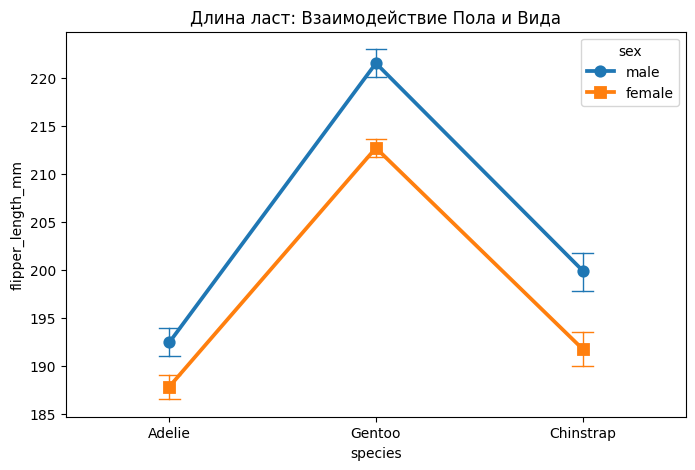

In [29]:
#Lab 35 




penguins['id'] = range(1, len(penguins) + 1)

penguins_means = penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].mean()
print("Средние значения по видам:\n", penguins_means)

penguins_clean_mass = penguins.dropna(subset=['body_mass_g', 'species'])

anova_mass = stats.f_oneway(
    penguins_clean_mass[penguins_clean_mass['species'] == 'Adelie']['body_mass_g'],
    penguins_clean_mass[penguins_clean_mass['species'] == 'Chinstrap']['body_mass_g'],
    penguins_clean_mass[penguins_clean_mass['species'] == 'Gentoo']['body_mass_g']
)
print(f"\nANOVA (Масса тела по видам): p-value = {anova_mass.pvalue:.3e}")

tukey_mass = pairwise_tukeyhsd(endog=penguins_clean_mass['body_mass_g'], groups=penguins_clean_mass['species'], alpha=0.05)
print("\nКритерий Тьюки (Масса тела):")
print(tukey_mass)

penguins_clean_flip = penguins.dropna(subset=['flipper_length_mm', 'species'])
anova_flip = stats.f_oneway(
    penguins_clean_flip[penguins_clean_flip['species'] == 'Adelie']['flipper_length_mm'],
    penguins_clean_flip[penguins_clean_flip['species'] == 'Chinstrap']['flipper_length_mm'],
    penguins_clean_flip[penguins_clean_flip['species'] == 'Gentoo']['flipper_length_mm']
)
print(f"\nANOVA (Длина ласт по видам): p-value = {anova_flip.pvalue:.3e}")

tukey_flip = pairwise_tukeyhsd(endog=penguins_clean_flip['flipper_length_mm'], groups=penguins_clean_flip['species'], alpha=0.05)
print("\nКритерий Тьюки (Длина ласт):")
print(tukey_flip)

penguins_clean_sex_species = penguins.dropna(subset=['flipper_length_mm', 'sex', 'species'])

# Строим модель (ols)
model = ols('flipper_length_mm ~ C(sex) * C(species)', data=penguins_clean_sex_species).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nДвухфакторный ANOVA (Длина ласт: sex * species):")
print(anova_table)
print(f"""Интерпретация: 
C(sex): p-value < 0.05 (Пол влияет на длину ласт)
C(species): p-value < 0.05 (Вид влияет на длину ласт)
C(sex):C(species) (Взаимодействие): p-value = 0.006 (Меньше 0.05)
Вывод: Взаимодействие есть. Разница в длине ласт между самцами и самками 
неодинакова для разных видов пингвинов (у Gentoo этот разрыв статистически значимо больше).""")

plt.figure(figsize=(8, 5))
sns.pointplot(data=penguins_clean_sex_species, x='species', y='flipper_length_mm', hue='sex', markers=['o', 's'], capsize=.1, err_kws={'linewidth': 1})
plt.title("Длина ласт: Взаимодействие Пола и Вида")
plt.show()